In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
from matplotlib.ticker import MaxNLocator

df1 = pd.read_csv("../../CSV/aglu/archive/cropland(no fallowland).csv")   # basin, country, year, Value
df2 = pd.read_csv("../../CSV/compare_region_basin/country_area_timeseries.csv")   # variable, basin, year, area

In [ ]:
years = [2020, 2050, 2100]

# 表1：agri value
df1_sub = df1[df1["year"].isin(years)].copy()
df1_sub["basin_country"] = df1_sub["country"] + "_" + df1_sub["basin"]
df1_sub = df1_sub.drop(columns="country")
df1_sub = df1_sub.drop(columns="basin")
# 表2：只保留 basin_agri
df2_sub = df2[
    (df2["variable"] == "basin_agri") &
    (df2["year"].isin(years))
].copy()
df1_sub["basin"]=df1_sub["basin_country"] 
df2_sub2 = df2[
    (df2["variable"] == "region_agri") &
    (df2["year"].isin(years))
].copy()

In [ ]:
df_merge1 = pd.merge(
    df1_sub,
    df2_sub,
    on=["basin", "year"],
    how="inner"
)
df_merge2 = pd.merge(
    df1_sub,
    df2_sub2,
    on=["basin", "year"],
    how="inner"
)
df_merge1
df_merge2

In [ ]:
def percent_within_band(x, y, tol=0.1):

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0)
    x = x[mask]
    y = y[mask]

    within = (y >= (1 - tol) * x) & (y <= (1 + tol) * x)
    return within.sum() / len(x) * 100


In [ ]:
xs, ys = [], []

for year in years:
    d = df_merge1[df_merge1["year"] == year]
    x = d["area"].values
    y = d["Value"].values

    mask = np.isfinite(x) & np.isfinite(y) & (x > 0)
    xs.append(x[mask])
    ys.append(y[mask])

global_min = min(np.min(v) for v in xs + ys)
global_max = max(np.max(v) for v in xs + ys)

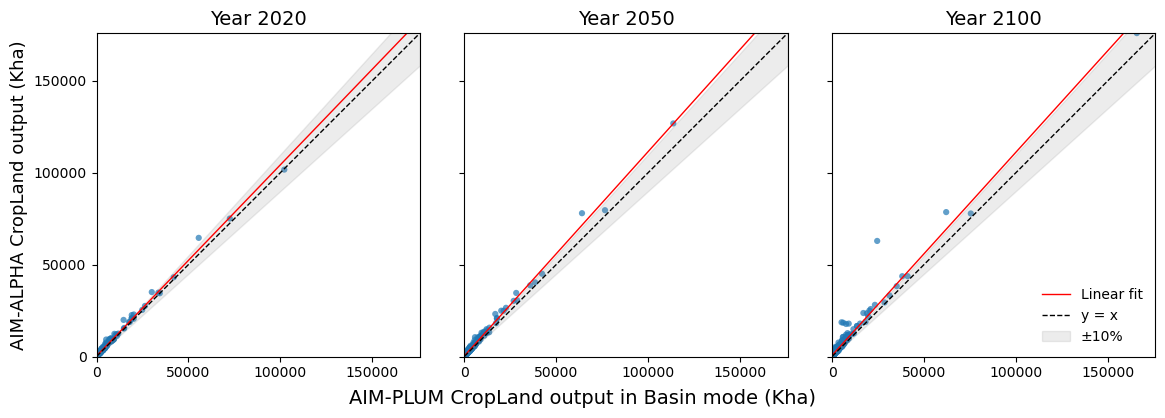

In [55]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
ticks = range(0,150001,50000)
for i, (ax, year) in enumerate(zip(axes, years)):
    d = df_merge1[df_merge1["year"] == year]

    x = d["area"].values        # AIM-PLUM
    y = d["Value"].values       # AIM-ALPHA

    # clean data (critical)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0)
    x = x[mask]
    y = y[mask]

    # scatter
    ax.scatter(x, y,s=20,color="tab:blue",alpha=0.7,edgecolors="none")
    
    if len(x) >= 2 and not np.allclose(x, x[0]):
        x_mean, x_std = x.mean(), x.std()
        y_mean, y_std = y.mean(), y.std()
        x_s = (x - x_mean) / x_std
        y_s = (y - y_mean) / y_std
        a_s, b_s = np.polyfit(x_s, y_s, 1)
        # back-transform
        a = a_s * (y_std / x_std)
        b = y_mean - a * x_mean

        use_log = False  # True = 对数坐标

        if use_log:
            ax.set_xscale("log")
            ax.set_yscale("log")
            x_line = np.logspace(np.log10(global_min),np.log10(global_max),
300)
        else:
            x_line = np.linspace(global_min, global_max, 300)
        
        ax.plot(x_line, a * x_line + b,color="red", linewidth=1,label="Linear fit")
        y_pred = a * x + b
        r2 = r2_score(y, y_pred)
        r2_id = r2_score(y, x)
        # ax.text(
        #     0.05, 0.88,
        #     f"$R^2$ = {r2_id:.2f}",
        #     transform=ax.transAxes,
        #     fontsize=11,
        #     va="top"
        # )
        xmin = min(x.min(), y.min())
        xmax = max(x.max(), y.max())

        ax.plot(
            [global_min, global_max], [global_min, global_max],
            linestyle="--", color="black", linewidth=1,
            label="y = x"
        )
        ax.fill_between(
            x_line,
            0.9 * x_line,
            1.1 * x_line,
            color="gray", alpha=0.15,
            label="±10%"
        )
    ax.set_xlim(global_min, global_max)
    ax.set_ylim(global_min, global_max)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)

    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"Year {year}", fontsize=14)

    if i == 0:
        ax.set_ylabel("AIM-ALPHA CropLand output (Kha)", fontsize=13)
    if i == 2:
        ax.legend(
            loc="lower right",
            fontsize=10,
            frameon=False
        )
fig.supxlabel(
    "AIM-PLUM CropLand output in Basin mode (Kha)",
    fontsize=14,
)
plt.tight_layout()
plt.savefig("../../plot/aglu/aglu_vs_plumbasin_cropland_area.png")
plt.savefig("../../plot/aglu/aglu_vs_plumbasin_cropland_area.svg")
plt.show()

In [ ]:
xs2, ys2 = [], []

for year in years:
    d2 = df_merge2[df_merge2["year"] == year]
    x2 = d2["area"].values
    y2 = d2["Value"].values

    mask = np.isfinite(x2) & np.isfinite(y2) & (x2 > 0)
    xs2.append(x2[mask])
    ys2.append(y2[mask])

global_min2 = min(np.min(v) for v in xs2 + ys2)
global_max2 = max(np.max(v) for v in xs2 + ys2)

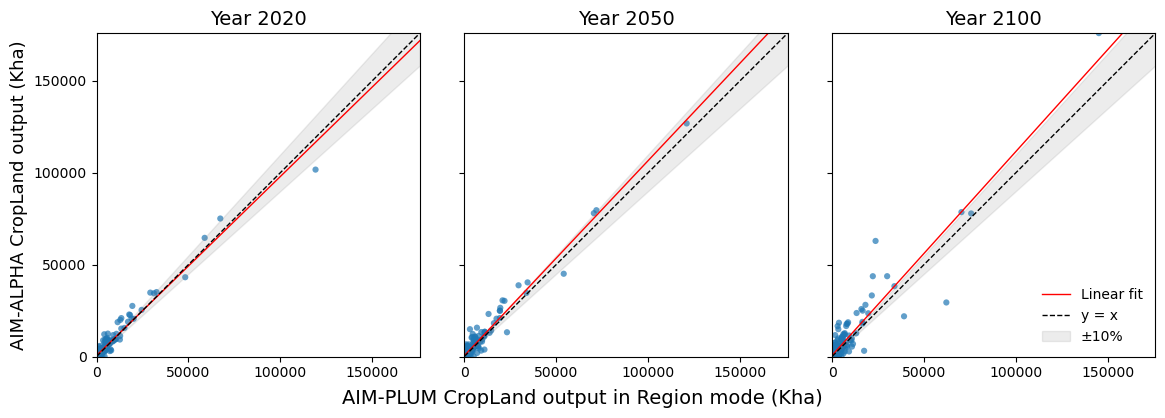

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

for i, (ax, year) in enumerate(zip(axes, years)):
    d = df_merge2[df_merge2["year"] == year]

    x = d["area"].values        # AIM-PLUM
    y = d["Value"].values       # AIM-ALPHA

    # clean data (critical)
    mask = np.isfinite(x) & np.isfinite(y) & (x > 0)
    x = x[mask]
    y = y[mask]

    # scatter
    ax.scatter(x, y,s=20,color="tab:blue",alpha=0.7,edgecolors="none")

    if len(x) >= 2 and not np.allclose(x, x[0]):
        # standardize to avoid SVD failure
        x_mean, x_std = x.mean(), x.std()
        y_mean, y_std = y.mean(), y.std()

        x_s = (x - x_mean) / x_std
        y_s = (y - y_mean) / y_std

        a_s, b_s = np.polyfit(x_s, y_s, 1)

        # back-transform
        a = a_s * (y_std / x_std)
        b = y_mean - a * x_mean
        use_log = False
        if use_log:
            ax.set_xscale("log")
            ax.set_yscale("log")
            x_line = np.logspace(
                np.log10(global_min),
                np.log10(global_max),
                300
            )
        else:
            x_line = np.linspace(global_min, global_max, 300)
            
        ax.plot(
            x_line, a * x_line + b,color="red", linewidth=1,label="Linear fit")
        y_pred = a * x + b
        r2 = r2_score(y, y_pred)
        r2_id = r2_score(y, x)
        # ax.text(0.05, 0.88,f"$R^2$ = {r2_id:.2f}",transform=ax.transAxes,fontsize=11,va="top")
        
        xmin = min(x.min(), y.min())
        xmax = max(x.max(), y.max())

        ax.plot(
            [global_min, global_max], [global_min, global_max],
            linestyle="--", color="black", linewidth=1,
            label="y = x"
        )

        ax.fill_between(
            x_line,
            0.9 * x_line,
            1.1 * x_line,
            color="gray", alpha=0.15,
            label="±10%"
        )
    ax.set_xlim(global_min2, global_max2)
    ax.set_ylim(global_min2, global_max2)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(f"Year {year}", fontsize=14)
    ax.set_xticks(ticks)
    ax.set_yticks(ticks)
    if i == 0:
        ax.set_ylabel("AIM-ALPHA CropLand output (Kha)", fontsize=13)
    if i == 2:
        ax.legend(
            loc="lower right",
            fontsize=10,
            frameon=False
        )
fig.supxlabel(
    "AIM-PLUM CropLand output in Region mode (Kha)",
    fontsize=14,
)
plt.tight_layout()
plt.savefig("../../plot/aglu/aglu_vs_plumregion_cropland_area.png")
plt.show()

In [ ]:
for year in years:
    d = df_merge1[df_merge1["year"] == year]
    y = d["area"].values
    x = d["Value"].values
    for i in np.arange(0.1,0.31,0.1):
        p = percent_within_band(x, y, tol=i)
        ii = i*100
        print(f"Basin {year}: {p:.1f}% within ±{ii:.0f}%")


In [ ]:
for year in years:
    d = df_merge2[df_merge2["year"] == year]
    y = d["area"].values
    x = d["Value"].values

    for i in np.arange(0.1,0.31,0.1):
        p = percent_within_band(x, y, tol=i)
        ii = i*100
        print(f"Region {year}: {p:.1f}% within ±{ii:.0f}%")


In [ ]:
# from sklearn.linear_model import LinearRegression
# from sklearn.metrics import r2_score
# import numpy as np
# import matplotlib.pyplot as plt
# from matplotlib.ticker import ScalarFormatter

# fig, axes = plt.subplots(
#     nrows=3,
#     ncols=2,
#     figsize=(5, 6),
#     sharex="col",
#     sharey=True
# )

# for row, year in enumerate(years):

#     # ===== 左列：Basin mode =====
#     ax = axes[row, 0]
#     d = df_merge1[df_merge1["year"] == year]

#     x = d["area"].values.reshape(-1, 1)
#     y_val = d["Value"].values

#     model = LinearRegression().fit(x, y_val)
#     r2 = r2_score(y_val, model.predict(x))

#     ax.scatter(x, y_val, alpha=0.7,s=10)


#     ax.text(
#         0.05, 0.95,
#         f"$R^2$ = {r2:.2f}",
#         transform=ax.transAxes,
#         fontsize=12,
#         va="top"
#     )

#     ax.set_title("Basin mode" if row == 0 else "", fontsize=12)
#     ax.set_ylabel(
#     f"{year}",
#     fontsize=12
# )

#     # ===== 右列：Region mode =====
#     ax = axes[row, 1]
#     d = df_merge2[df_merge2["year"] == year]

#     x = d["area"].values.reshape(-1, 1)
#     y_val = d["Value"].values

#     model = LinearRegression().fit(x, y_val)
#     r2 = r2_score(y_val, model.predict(x))

#     ax.scatter(x, y_val, alpha=0.7,s=10)

#     ax.text(
#         0.05, 0.95,
#         f"$R^2$ = {r2:.2f}",
#         transform=ax.transAxes,
#         fontsize=12,
#         va="top"
#     )

#     ax.set_title("Region mode" if row == 0 else "", fontsize=12)

# fig.supylabel(
#     "AIM-ALPHA CropLand output (Kha)",
#     fontsize=14,
#     x=0.04
# )

# # ===== 统一 x 轴标签（底部）=====
# fig.supxlabel(
#     "AIM-PLUM CropLand output (Kha)",
#     fontsize=14,
#     y=0.04
# )

# plt.tight_layout()
# plt.savefig(
#     "../../plot/aglu/aglu_vs_plum_basin_region_3x2.png",
#     dpi=300
# )
# plt.show()
